<a href="https://colab.research.google.com/github/martalgc26/procesos_estocasticos/blob/main/GPs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**SIMULAR Y VISUALIZAR GPs**

In [138]:
# Importamos los módulos necesarios para la implementación

import numpy as np #para manejar los datos
import matplotlib.pyplot as plt #para graficar

## **1. Muestras de una normal multivariante / multidimensional**

Para simular trayectorias de un GP vamos a necesitar simular muestras de una **Distribución normal multivariante**.

En el siguiente código se muestra como obtener $n=50$ muestras de un vector aleatorio 3-dimensional $\mathbf{X} = (X_1, X_2, X_3)^T$ que sigue una distribución normal $$\mathbf{X} \sim \mathcal{N}(0,I_{3\times 3})$$

Para ello, hemos utilizado la función `np.random.multivariate_normal`, la cual extrae muestras aleatorias usando la factoriazación de la matriz de covarianzas mediante la descomposición de Cholesky ($\boldsymbol{\Sigma} = LL^T$, donde $L$ es una matriz triangular inferior)

Al final se visualiza el array obtenido con las muestras generadas junto con su shape.



In [139]:
# Configuramos los parámetros de la función para crear las muestras
vector_medias = np.zeros(3) #vector de longitud 3 de 0's
matriz_covarianzas = np.eye(3) #matriz identidad de orden 3
num_samples = 50

# Generamos las muestras
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas,num_samples)

# Visualizamos las dimensiones
print("Shape: ", samples.shape) #(50,3) 50 muestras x 3 componentes

# Visualizamos las muestras obtenidas
print("Muestras: ")
print(samples)


Shape:  (50, 3)
Muestras: 
[[ 8.91400380e-01  1.16034893e+00 -1.82027835e+00]
 [ 1.21589950e-01  4.61484167e-01  1.91202575e-02]
 [-5.33678150e-01 -1.47148531e+00 -8.66729452e-01]
 [ 1.20973512e+00 -2.07125367e+00  1.05346061e+00]
 [-8.97965288e-01 -1.83572307e-01 -7.18915178e-01]
 [-5.03229354e-01 -1.59705300e+00 -1.62094045e+00]
 [ 2.76442716e-01  1.12878541e-01 -2.54506188e-01]
 [-8.55911516e-01 -2.06733473e-01  1.20492161e+00]
 [ 1.70998870e-01 -2.33732314e+00 -1.81139734e+00]
 [-7.42933259e-02 -4.37054131e-01  8.25885984e-01]
 [-8.66103332e-01  1.24854755e+00  1.81103596e+00]
 [-1.42223497e-01 -7.79974044e-01  7.96003229e-01]
 [ 1.95011034e-01  1.28795815e+00 -6.60292763e-02]
 [ 8.95844756e-01  6.56271321e-01 -1.46710574e+00]
 [-1.06127680e+00  9.13658175e-01 -2.21156004e-01]
 [-7.77131157e-01  7.59063151e-01  1.08285359e+00]
 [ 1.04424093e+00 -5.15971508e-01 -2.33885379e+00]
 [ 4.53953922e-03 -1.06226941e+00 -6.56348402e-01]
 [-1.89192101e+00  2.73147843e-01  9.84628033e-01]
 [-1

Ahora, repetiremos el proceso pero para una normal con matriz de covarianzas que no sea la identidad, sino:

 $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

**Análisis de diferencias**

En este caso el vector de medias no ha cambiado, solo hemos modificado los valores de la diagonal principal, donde se encuentran las varianzas de cada componente ($\sigma^2_i$).
Por tanto, se producen cambios en la dispersión de los datos pues la variable $X_1$ sigue teniendo una dispersión pequeña($\sigma^2_1 = 1$) pero las variables $X_2$ y $X_3$ aumentan significativamente su variabilidad tomando valores mucho más alejados del origen. Esto provoca que la "nube de puntos" cambie y se estire en las direcciones de los ejes $Y$ y $Z$ .

Por el contrario, daod que los elementos fuera de la diagonal siguen siendo cero ($Cov(X_i, X_j) = 0$), se mantiene la independencia lineal entre las variables.


In [140]:
# Configuramos los parámetros de la función para crear las muestras
vector_medias = np.zeros(3) #vector de longitud 3 de 0's
matriz_covarianzas = np.diag([1,10,100]) #matriz diagonal de orden 3 con los vlaores dados
num_samples = 50

# Generamos las muestras
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas,num_samples)

# Visualizamos las dimensiones
print("Shape: ", samples.shape) #(50,3) 50 muestras x 3 componentes

# Visualizamos las muestras obtenidas
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[-2.30838907e-01  2.38973169e+00 -5.50528379e-02]
 [ 2.02332025e+00 -8.74620880e-01  3.15233420e-01]
 [-6.65022081e-02 -2.53497003e+00  1.11745246e+01]
 [-8.23215996e-01  2.39557817e+00  2.35366973e-01]
 [ 5.42586936e-01  1.16005753e-01 -1.37106241e+01]
 [ 5.04779686e-01  4.87545309e+00 -4.86838214e-01]
 [-1.49832341e+00  4.02354249e+00  9.72080140e+00]
 [ 1.81751361e+00 -3.33614447e+00 -6.66911626e+00]
 [-3.74227126e-01 -1.00213841e+00 -6.89689844e+00]
 [-5.36776425e-02  9.14749267e-01 -1.34542053e+01]
 [ 1.53106016e+00  1.64330943e+00  1.40568876e+01]
 [-1.89511917e+00  1.80481007e-01 -2.81665613e+00]
 [ 2.13343198e-01 -6.88040051e-01  2.72704769e+01]
 [ 1.60474464e-01 -2.17747869e+00 -1.43523214e+01]
 [ 5.58368580e-01  2.00379192e+00 -1.54639394e-01]
 [ 2.82990601e-01  4.70019406e+00 -1.34340013e+01]
 [ 2.44670219e-01 -2.58031898e+00 -2.86852088e-01]
 [ 1.02663769e+00  1.56637302e+00  6.51934920e+00]
 [-1.06536044e+00  1.24049221e+00  6.39053008e+00]
 [-8


## **2. Simular un GP con kernel RBF**

En este código implementamos el **Kernel RBF** definido como:

$$k(t_1, t_2) = \sigma^2 \cdot \exp\left( -\frac{1}{2} \cdot \left(\frac{|t_1 - t_2|}{\ell}\right)^2 \right)$$

Se trata de un kernel isotrópico válido en el cual la covarianza decrece con la distancia, es decir cuanto más lejos estén $t_1$ y $t_2$, menor será la covarianza entre $X_{t_1}$ y $X_{t_2}$.

Dicho kernel depende de dos hiperparámetros:

* **Varianza o amplitud ($\sigma^2$)**: controla la varianza de $X_t$ en cada instante $t \in T$ (la dispersión vertical de las trayectorias).
* **Escala de longitud o lengthscale ($\ell$)**: controla cuál es la unidad de medida de las distancias en el espacio de $t$, es decir, determina lo rápido que varían los valores de la función:
  - Cuando $\ell \to +\infty$ :los instantes $t_1$ y $t_2$ se consideran cerca y la covarianza tiende al máximo luego hay mucha correlación entre $X_{t_1}$ y $X_{t_2}$ y las trayectorias del GP varian muy poco en diferentes t (son casi constantes).
   - Cuando $\ell \to 0$: los instantes $t_1$ y $t_2$ están lejos y la covarianza tiende a 0 luego hay poca correlación entre $X_{t_1}$ y $X_{t_2}$ y las trayectorias del GP varian muy mucho en diferentes t.


### **Visualización trayectorias**
En esta sección, se definirá la función `simular_GP_RBF` que nos permitirá simular trayectorias de un GP con kernel RBF y función de medias constantemente igual a cero que se usará para generar gráficas similares a las vistas en las diapositivas de clase.

In [141]:
def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
  """
  Simula trayectorias dn un GP con kernel RBF y funcion de medias ctemente = 0.

  Input:
  t: np.array (n,)
     vector de localizaciones en los que se quiere simular el GP
  sigma_sq: float
     varianza del kernel
  lengthscale:float
     parámetro de escala del kernel
  num_samples: int
    número de muestras a generar

  -------
  Output:
  samples: np.array (num_samples,n)
     muestras del GP generadas
  """

  # Defnimos el vector de medias (mu(t)=0 para todo t)
  # 'np.zeros_like' crea un vector de ceros con la misma forma que t de forma eficiente
  vector_medias = np.zeros_like(t)

  # Calculamos la matriz de covarianzas usando la fórmula del kernel RBF
  # Aplicamos "Broadcasting" para calcular primero la matriz de distancias entre instantes
  # t[:,np.newaxis] convierte vector t (n,) en (n,1)
  distancias = t[:,np.newaxis] - t[np.newaxis,:] #tamaño (n,n)
  # Una vez calculadadas todas las distancias aplicamos la fórmula a cada una
  matriz_covs = sigma_sq * np.exp(-0.5*(distancias/lengthscale)**2)

  # Obtengo 'num_samples' de trayectorias aplicando la def de GP
  samples = np.random.multivariate_normal(vector_medias, matriz_covs,num_samples)

  return samples

**En primer lugar**,  veremos el efecto de $\sigma$ manteniendo fijo el parámetro $\ell=1$, y graficando el GP para distintos valores de amplitud. En este caso vemos entonces cómo cambia el rango de los valores en el eje Y.

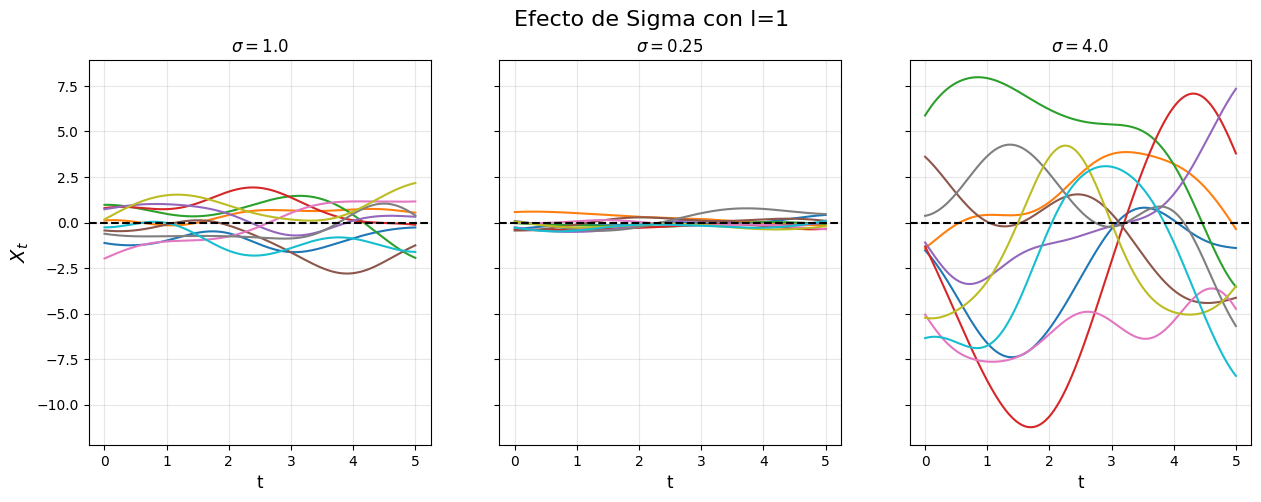

In [142]:
# ---- Configuración parámetros ----

n_samples = 10 # número de trayectorias
t = np.linspace(0,5,1000) # conjuntos de instantes donde evaluar el GP
sg_sqrt = np.array([1,0.25,4]) # valores de parámetro amplitud (lo cambiamos para cada visualización)
ls = np.array([1,1,1]) # valores parámetro lengthscale (ctemente = 1)


# ----- Configuación de la figura -----

# Figura base de Marplotlib con 3 subfiguras con ejes compartidos
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Configuro el título general
fig.suptitle('Efecto de Sigma con l=1', fontsize=16)

# Bucle para generar los 3 gráficos con cada valor de Sigma
for i,ax in enumerate(axes):

  # Obtengo los datos de las trayectorias
  samples = simular_GP_RBF(t,sg_sqrt[i]**2,ls[i],n_samples)

  # Dibujo las trayectorias generadas (samples tiene dim (10,1000))
  ax.plot(t,samples.T) # plot interpreta los datos en columnas

  # Configuro el título dinámico de cada subgráfico
  ax.set_title(rf"$\sigma = {sg_sqrt[i]}$")

  # Añado la línea de la media
  ax.axhline(0, color='black', linestyle='--')

  # Label del Eje X para cada gráfico
  ax.set_xlabel('t', fontsize=12)

  # Añadimos la cuadricula ajustando su transparencia
  ax.grid(True, linestyle='-', alpha=0.3)

# Configuramos el label del eje Y solo en el primer gráfico (donde esta numerado el eje)
axes[0].set_ylabel('$X_t$', fontsize=14)

plt.show()

**En segundo lugar**, visualizaremos el efecto de $\ell$. Para ello mantendremos fija la varianza $\sigma=1$, y variaremos la escala de longitud para observar cómo afecta a la "variabilidad" de las trayectorias.

In [ ]:
# ---- Configuración parámetros ----

n_samples = 10 # número de trayectorias
t = np.linspace(0,5,1000) # conjuntos de instantes donde evaluar el GP
sg_sqrt = np.array([1,1,1]) # valores de parámetro amplitud  (ctemente = 1)
ls = np.array([0.25,1,4]) # valores parámetro lengthscale (lo cambiamos para cada visualización)


# ----- Configuación de la figura -----

# Figura base de Marplotlib con 3 subfiguras con ejes compartidos
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Configuro el título general
fig.suptitle(r"Efecto de LengthScale con $l = 1$")

# Bucle para generar los 3 gráficos con cada valor de Sigma
for i,ax in enumerate(axes):

  # Obtengo los datos de las trayectorias
  samples = simular_GP_RBF(t,sg_sqrt[i]**2,ls[i],n_samples)

  # Dibujo las trayectorias generadas (samples tiene dim (10,1000))
  ax.plot(t,samples.T) # plot interpreta los datos en columnas

  # Configuro el título dinámico de cada subgráfico
  ax.set_title(rf"$l = {ls[i]}$")

  # Añado la línea de la media
  ax.axhline(0, color='black', linestyle='--')

  # Label del Eje X para cada gráfico
  ax.set_xlabel('t', fontsize=12)

  # Añadimos la cuadricula ajustando su transparencia
  ax.grid(True, linestyle='-', alpha=0.3)

# Configuramos el label del eje Y solo en el primer gráfico (donde esta numerado el eje)
axes[0].set_ylabel('$X_t$', fontsize=14)

plt.show()


## **3. Simular un GP con kernel periódico**

En este código implementamos el Kernel Periódico definido como:

$$k(t_1, t_2) = \sigma^2 \cdot \exp\left( -\frac{2}{\ell^2} \cdot \sin^2\left(\pi \cdot \frac{|t_1 - t_2|}{p}\right) \right)$$

Se trata de un kernel estacionario válido en el cual la covarianza modela funciones con un comportamiento cíclico, es decir, la correlación vuelve a ser máxima cada vez que la distancia entre $t_1$ y $t_2$ es un múltiplo exacto del periodo.

En esta ocasión kernel depende de tres hiperparámetros:
- Varianza o amplitud ($\sigma^2$)
- Periodo ($p$): determina la distancia en el espacio de $t$ entre repeticiones de la trayectoria (el tiempo que tarda en completarse un ciclo).
- Escala de longitud o lengthscale ($\ell$)

### **Visualización trayectorias**
En esta sección vamos a definir una función `simular_GP_periodic` que nos permitirá simular trayectorias de un GP con kernel periódico y función de medias constantemente igual a cero que se usará para generar gráficas similares a las de las diapositivas.

In [ ]:
def simular_GP_periodico(t, sigma_sq=1, lengthscale=1, period=1, num_samples=1):
  """
  Simula trayectorias dn un GP con kernel RBF  periodico y funcion de medias ctemente = 0.

  Input:
  t: np.array (n,)
     vector de localizaciones en los que se quiere simular el GP
  sigma_sq: float
     varianza del kernel
  lengthscale:float
     parámetro de escala del kernel
  period: float
     parámetro de periodo del kernel
  num_samples: int
    número de muestras a generar

  -------
  Output:
  samples: np.array (num_samples,n)
     muestras del GP generadas
  """

  # Defnimos el vector de medias (mu(t)=0 para todo t)
  # 'np.zeros_like' crea un vector de ceros con la misma forma que t de forma eficiente
  vector_medias = np.zeros_like(t)

  # Calculamos la matriz de covarianzas usando la fórmula del kernel RBF
  # Aplicamos "Broadcasting" para calcular primero la matriz de distancias entre instantes
  # t[:,np.newaxis] convierte vector t (n,) en (n,1)
  distancias = t[:,np.newaxis] - t[np.newaxis,:] #tamaño (n,n)
  # Una vez calculadadas todas las distancias aplicamos la fórmula a cada una
  matriz_covs = sigma_sq*np.exp((-1/lengthscale**2)*(np.sin(np.pi*distancias/period))**2)

  # Obtengo 'num_samples' de trayectorias aplicando la def de GP
  samples = np.random.multivariate_normal(vector_medias, matriz_covs,num_samples)

  return samples

**En primer lugar**, visualizaremos el efecto de $\ell$. Para ello mantendremos fija la varianza $\sigma=1$ y el periodo $p=1$, y variaremos la escala de longitud para observar cómo afecta a la "variabilidad" de las trayectorias.

In [ ]:
# ---- Configuración parámetros ----

n_samples = 2 # número de trayectorias
t = np.linspace(0,5,1000) # conjuntos de instantes donde evaluar el GP
sg_sqrt = np.array([1,1]) # valores de parámetro amplitud  (ctemente = 1)
ls = np.array([0.25,4]) # valores parámetro lengthscale (lo cambiamos para cada visualización)
period = np.array([1,1]) # valores de parámetro periodo  (ctemente = 1)

# ----- Configuación de la figura -----

# Figura base de Marplotlib con 2 subfiguras con ejes compartidos
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for i,ax in enumerate(axes):

  # Obtengo los datos de las trayectorias
  samples = simular_GP_periodico(t,sg_sqrt[i]**2,ls[i],period[i],n_samples)

  # Dibujo las trayectorias generadas (samples tiene dim (10,1000))
  ax.plot(t,samples.T) # plot interpreta los datos en columnas

  # Configuro el título dinámico de cada subgráfico
  ax.set_title(rf"GP periodico ($l = {ls[i]}$)")

  # Ajusto label Eje X para cada gráfico
  ax.set_xlabel('t', fontsize=12)

  # Añadimos la cuadricula ajustando su transparencia
  ax.grid(True, linestyle='-', alpha=0.3)

# Configuramos la etiqueta del eje Y solo en el primer gráfico (donde esta numerado el eje)
axes[0].set_ylabel('$X_t$', fontsize=14)

plt.show()

**En segundo lugar**, visualizaremos el efecto del periodo $p$. Para ello mantendremos fija la varianza $\sigma=1$ y el lengthscale $\ell=1$, y variaremos la periodicidad de las trayectorias.

In [ ]:
# ---- Configuración parámetros ----

n_samples = 2 # número de trayectorias
t = np.linspace(0,5,1000) # conjuntos de instantes donde evaluar el GP
sg_sqrt = np.array([1,1]) # valores de parámetro amplitud  (ctemente = 1)
ls = np.array([1,1]) # valores parámetro lengthscale (ctemente = 1)
period = np.array([1,2.5]) # valores de parámetro periodo (lo cambiamos para cada visualización)

# ----- Configuación de la figura -----

# Figura base de Marplotlib con 2 subfiguras con ejes compartidos
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for i,ax in enumerate(axes):

  # Obtengo los datos de las trayectorias
  samples = simular_GP_periodico(t,sg_sqrt[i]**2,ls[i],period[i],n_samples)

  # Dibujo las trayectorias generadas (samples tiene dim (10,1000))
  ax.plot(t,samples.T) # plot interpreta los datos en columnas

  # Configuro el título dinámico de cada subgráfico
  ax.set_title(rf"GP periodico ($p = {period[i]}$)")

  # Ajusto label Eje X para cada gráfico
  ax.set_xlabel('t', fontsize=12)

  # Añadimos la cuadricula ajustando su transparencia
  ax.grid(True, linestyle='-', alpha=0.3)

# Configuramos la etiqueta del eje Y solo en el primer gráfico (donde esta numerado el eje)
axes[0].set_ylabel('$X_t$', fontsize=14)

plt.show()


**En tercer lugar**,  veremos el efecto de $\sigma$ manteniendo fijo el parámetro $\ell=1$ y $p=1$, y graficando el GP para distintos valores de amplitud. En este caso vemos entonces cómo cambia el rango de los valores en el eje Y.

In [ ]:
# ---- Configuración parámetros ----

n_samples = 2 # número de trayectorias
t = np.linspace(0,5,1000) # conjuntos de instantes donde evaluar el GP
sg_sqrt = np.array([1,4]) # valores de parámetro amplitud (lo cambiamos para cada visualización)
ls = np.array([1,1]) # valores parámetro lengthscale (ctemente = 1)
period = np.array([1,1]) # valores de parámetro periodo

# ----- Configuación de la figura -----

# Figura base de Marplotlib con 2 subfiguras con ejes compartidos
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for i,ax in enumerate(axes):

  # Obtengo los datos de las trayectorias
  samples = simular_GP_periodico(t,sg_sqrt[i]**2,ls[i],period[i],n_samples)

  # Dibujo las trayectorias generadas (samples tiene dim (10,1000))
  ax.plot(t,samples.T) # plot interpreta los datos en columnas

  # Configuro el título dinámico de cada subgráfico
  ax.set_title(rf"GP periodico ($\sigma = {sg_sqrt[i]}$)")

  # Ajusto label Eje X para cada gráfico
  ax.set_xlabel('t', fontsize=12)

  # Añadimos la cuadricula ajustando su transparencia
  ax.grid(True, linestyle='-', alpha=0.3)

# Configuramos la etiqueta del eje Y solo en el primer gráfico (donde esta numerado el eje)
axes[0].set_ylabel('$X_t$', fontsize=14)

plt.show()


##**4. Simular un GP con kernel DPK (concretamente, polinómico hasta grado $m$)**

Sean $f_1,\dots,f_m$ funciones de $T$ en $\mathbb{R}$.

Se define el DPK asociado a $f_1, \ldots, f_m$ como:

$$ k(t_1, t_2) = \sum_{i=1}^{m} f_i(t_1)\, f_i(t_2)$$

En este caso concreto se usaran como funciones base los monomios de grado hasta $m$, es decir $\{1, t,\dots,t^m\}$.

Luego el **kernel DPK polonómico** quedaría definido como:
$$ k(t_1, t_2) = \sum_{i=0}^{m} (t_1\,t_2)^i$$

Este kernel mide la similitud entre dos puntos $t_1$ y $t_2$ como una combinación de productos polinómicosy da lugar a GP cuyas trayectorias pueden expresarse como combinaciones
de polinomios hasta grado $m$.



### **Visualización de trayectorias**

En esta sección vamos a definir una función `simular_GP_DPKpoly` que nos permita simular de un GP con kernel DPK polinómico y función de medias constantemente igual a cero.Dicha función será utilizada para generar gráficos similares a los de las diapositivas.

In [ ]:
def simular_GP_DPKpoly_1(t,m=1,num_samples=1):

  """
  Simula trayectorias de un Proceso Gaussiano (GP) con kernel DPK con funciones polinómicas.

  Input:
  t: np.array (n,)
    vector de localizaciones en los que se quiere simular el GP
  m: int
    grado máximo de las funciones polinomicas del kernel
  num_samples: int
    número de muestras a generar

  -------
  Output:
  samples: np.array (n, num_samples)
    muestras del GP generadas
  """

  n = len(t)

  # Definimos el vector de medias (mu(t)=0 para todo t)
  # 'np.zeros_like' crea un vector de ceros con la misma forma que t de forma eficiente
  vector_medias = np.zeros_like(t)

  # Calculamos la matriz de covarianzas usando como funciones base polinomios de hasta grado m
  # Calculamos todos los productos entre intantes t_i*t_j usando "Broadcasting"
  # t[:,np.newaxis] convierte vector t (n,) en (n,1) y t[np.newaxis, :] convierte t (n,) en (1,n)
  prod_T = t[:,np.newaxis] * t[np.newaxis,:]

  # Inicializamos la matriz de covarianzas de dim (n,n)
  matriz_covs = np.zeros((n,n))

  # Construimos el kernel usando la defición
  for i in range(m+1):
    matriz_covs += prod_T ** i

  # Añadimos "jitter" en la diagonal para asegurar que la matriz siga siendo semidef positiva
  jitter = 1e-6
  matriz_covs += np.eye(n)*jitter

  # Obtenemos las muestras del GP
  samples = np.random.multivariate_normal(vector_medias, matriz_covs,num_samples)

  return samples

In [ ]:
# ---- Configuración parámetros ----

n_samples = 5  # número de trayectorias a simular
t = np.linspace(-10, 10, 1000)  # conjunto de instantes donde evaluar el GP


# ----- Configuración de la figura -----

# Figura base de Matplotlib con 3 subgráficos y eje Y compartido
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Bucle para generar los 3 gráficos con distintos grados del kernel polinómico
for i, ax in enumerate(axes):

    # Definimos el grado máximo del polinomio (funciones base del kernel)
    degree = i + 1

    # Obtengo los datos de las trayectorias del GP para ese grado
    samples = simular_GP_DPKpoly_1(t, degree, n_samples)

    # Dibujo las trayectorias generadas
    ax.plot(t, samples.T)# plot interpreta los datos en columnas

    # Configuro el título dinámico de cada subgráfico
    ax.set_title(rf"GP con kernel DPK $m = {degree}$")

    # Configuro el label del eje X para cada gráfico
    ax.set_xlabel('t', fontsize=12)

    # Añadimos la cuadrícula ajustando su transparencia
    ax.grid(True, linestyle='-', alpha=0.3)


# Configuramos el label y límites del eje Y solo en el primer gráfico
axes[0].set_ylabel('$X_t$', fontsize=14)
axes[0].set_ylim([-20, 20])

# Mostramos la figura final
plt.show()

###**Otra posible solución**

En clase se demostró a través de una serie de ejercicios que las trayectorias de un GP con kernel DPK y funcion de medias constantemente igual a cero se pueden describir como combinación lineal de las funciones base $\{f_1, \dots, f_m\}$, es decir:

$$X(t) = \sum_{j=0}^{m} A_j \, f_j(t)$$

donde los coeficientes siguen una distribución normal multivariante:

$$\mathbf{A}=(A_1,\dots,A_m) \sim \mathcal{N}(0, I_m)$$

Aplicamos esta manera de construir las trayectorias de un GP tomando como funciones base los monomios de hasta grado $m$, es decir $\{1,t,\dots, t^m\}$


In [ ]:
def simular_GP_DPKpoly_2(t,m=1,num_samples=1):

  """
  Simula trayectorias de un Proceso Gaussiano (GP) con kernel DPK con funciones polinómicas.

  Input:
  t: np.array (n,)
    vector de localizaciones en los que se quiere simular el GP
  m: int
    grado máximo de las funciones polinomicas del kernel
  num_samples: int
    número de muestras a generar

  -------
  Output:
  samples: np.array (n, num_samples)
    muestras del GP generadas
  """

  # Genero los coeficientes que siguen una normal multivariante (0,Id) para cada trayectoria a dibujar --> dim = (num_samples,m+1)
  vector_medias = np.zeros(m+1)
  matriz_covarianzas = np.eye(m+1)
  coef = np.random.multivariate_normal(vector_medias, matriz_covarianzas,num_samples) #shape (num_samples,m+1)

  # Construyo la matriz de funciones base
  # Genero la matriz de potencias de t hasta grado m (desde grado 0)
  # 'np.vstack' las apila en vertical
  pot_T = np.vstack([t**j for j in range(m+1)]) #shape(m+1,n)


  # Hago producto matricial entre coeficientes y las potencias para obtener los datos de cada trayectoria
  samples = np.dot(coef, pot_T) # shape (num_samples, n)

  return samples

In [ ]:
# ---- Configuración parámetros ----

n_samples = 5  # número de trayectorias a simular
t = np.linspace(-10, 10, 1000)  # conjunto de instantes donde evaluar el GP


# ----- Configuración de la figura -----

# Figura base de Matplotlib con 3 subgráficos y eje Y compartido
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Bucle para generar los 3 gráficos con distintos grados del kernel polinómico
for i, ax in enumerate(axes):

    # Definimos el grado máximo del polinomio (funciones base del kernel)
    degree = i + 1

    # Obtengo los datos de las trayectorias del GP para ese grado
    samples = simular_GP_DPKpoly_2(t, degree, n_samples)

    # Dibujo las trayectorias generadas
    ax.plot(t, samples.T)# plot interpreta los datos en columnas


    # Configuro el título dinámico de cada subgráfico
    ax.set_title(rf"GP con kernel DPK $m = {degree}$")

    # Configuro el label del eje X para cada gráfico
    ax.set_xlabel('t', fontsize=12)

    # Añadimos la cuadrícula ajustando su transparencia
    ax.grid(True, linestyle='-', alpha=0.3)


# Configuramos el label y límites del eje Y solo en el primer gráfico
axes[0].set_ylabel('$X_t$', fontsize=14)
axes[0].set_ylim([-20, 20])

# Mostramos la figura final
plt.show()

## **5.¿Cómo hacer que el kernel se pase como parámetro? ¿y la función de medias?**
(Solución proporcionada en archivo base)

Estas preguntas, bastante generales, se pueden abordar de muchas maneras. En esta sección se presenta muy brevemente una solución basada en el paradigma de programación orientada a objetos (POO). Es la manera más habitual de programar en Python y en muchos otros lenguajes.

La idea de la POO es estructurar el código usando el concepto de _clase_. Una _clase_ es algo ``parecido'' a un _struct_, que probablemente se viese en las asignaturas de C++, aunque una clase tiene mayor funcionalidad. Concretamente, una _clase_ es una estructura que nos permite crear objetos que contienen dos cosas principalmente:
* Atributos: valores que forman parte del objeto.
* Métodos: acciones que puede realizar el objeto.

A continuación definimos una _clase_ para describir el kernel RBF. La clase define dos atributos:
* ```self.sigma_sq```: es el parámetro $\sigma^2$.
* ```self.lengthscale```: es el parámetro $\ell$.
Y la clase define un método (además del ```__init__``` básico, que se usa para crear un objeto de la clase):
* ```__call__(self, t, s)```: permite evaluar el kernel usando como inputs los arrays t y s. Es decir, calcula la matriz $(k(t_i, s_j))_{ij}$.

In [ ]:
class RBF:
  def __init__(self, sigma_sq=1, lengthscale=1):
    self.sigma_sq = sigma_sq
    self.lengthscale = lengthscale
  def __call__(self, t, s):
    dists = t[:, None] - s[None, :]
    cov_matrix = self.sigma_sq * np.exp(-0.5 * (dists / self.lengthscale)**2)
    return cov_matrix

En la celda anterior simplemente hemos definido "qué es un objeto de tipo RBF".

En la celda siguiente, utilizamos la clase recién definida para crear un objeto concreto de ese tipo:

In [ ]:
my_kernel = RBF(sigma_sq=1, lengthscale=1)
print(type(my_kernel))  # Deberíamos ver que este objeto es de tipo "RBF"

t = np.linspace(0,10,100)
cov_mat = my_kernel(t,t)   # Aquí estamos usando el método __call__ (es un método especial que se utiliza de esta manera)
print(cov_mat.shape)  # Aquí deberíamos obtener una matriz con shape (100, 100), puesto que es la matriz de covarianzas de evaluar el GP en t (que tiene tamaño 100)

A continuación definimos una clase para la función de medias constantemente igual a cero:

In [ ]:
class Zero_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return np.zeros_like(t)

Y creamos un objeto de ese tipo:

In [ ]:
my_mf = Zero_Mean_Function()
print(type(my_mf))

mean = my_mf(t)
print(mean.shape)
print((mean==0).all())

Definimos ahora una función ```simular_GP``` que recibe como parámetros __cualquier función de medias__ (```mf```) y __cualquier kernel__ (```kernel```). Lo único que necesitamos es que sean objetos de clases en las que se haya definido el método ```__call__``` igual que se ha hecho arriba.

In [ ]:
def simular_GP(t, mf, kernel, num_samples=1):
  vector_medias = mf(t)
  matriz_covs = kernel(t,t)
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)
  return samples

Para validar esta función, vamos a generar la imagen de la diapositiva 64, donde se usaba la función de medias identidad y el kernel RBF.

Para ello, definimos una clase para la función de medias identidad:

In [ ]:
class Identity_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return t

Finalmente, usamos esta clase, la clase RBF, y la función ```simular_GP``` para obtener lo buscado:

In [ ]:
my_identity_mf = Identity_Mean_Function()
sigma = 1
lengthscale = 1
my_rbf_kernel = RBF(sigma_sq=sigma**2, lengthscale=lengthscale)
t = np.linspace(0,5,500)
num_samples = 10
samples = simular_GP(t, my_identity_mf, my_rbf_kernel, num_samples=num_samples)

for i in range(num_samples):
  plt.plot(t, samples[i,:])
plt.plot(t, my_identity_mf(t), color='black', linestyle="--")
plt.title(f"GP with identity mean function (RBF kernel: sigma: {sigma}; lengthscale:{lengthscale})")
plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.grid(True, alpha=0.3)
plt.show()


## **Referencias**

Toda la teoría, fórmulas y definiciones que he utilizado como referencia para programar estas simulaciones del PAS provienen de:
* **Morales Álvarez, P.** (*s.f.*). *Tema 1: Teoría general de Procesos Estocásticos. Algunos ejemplos* [Diapositivas de clase]. Universidad de Granada.